# Final ground-truth comparison: 2-channel versus 4-channel models

This notebook compares Dataset 709 (**4-channel: fat, water, in-phase, fat fraction**) and Dataset 710 (**2-channel: fat, water**) against the Jordan ground-truth masks in `/mnt/DATAHDD/jordan/SegmentationMask`.

The main table follows the requested publication format. Each cell reports **mean ± standard deviation** across 48 paired ground-truth scans. Dice (DSC) is higher-is-better; HD95 and ASSD are symmetric surface distances in millimetres and are lower-is-better.

Selected labels are SAT, IMAT, IMF, and bilateral rectus femoris. Bilateral rectus femoris is the union of its left and right reference/prediction labels.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, wilcoxon

ROOT = Path.cwd()
ANALYSIS = ROOT / 'volumetric_analysis'
DATA_DIR = ANALYSIS / 'channel_comparison'
FIG_DIR = ANALYSIS / 'notebooks' / 'figures' / 'final'
FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics = pd.read_csv(DATA_DIR / 'selected_label_surface_metrics.csv')
metrics['Dataset'] = metrics['Dataset'].astype(int)
model_order = ['DeepLab', 'SwinUNETR', 'TopK']
channel_order = ['4-channel', '2-channel']
label_order = ['SAT', 'IMAT', 'IMF', 'Rectus femoris']
label_key = {'SAT': 'SAT', 'IMAT': 'IMAT', 'IMF': 'IMF',
             'Rectus femoris': 'rectus_femoris_bilateral'}
metric_columns = [('DSC', 'Dice'), ('HD95 (mm)', 'HD95_mm'), ('ASSD (mm)', 'ASSD_mm')]
sns.set_theme(style='whitegrid', context='notebook')

print(f'Loaded {len(metrics):,} metric rows from {metrics.Scan.nunique()} scans.')
print('Ground truth: /mnt/DATAHDD/jordan/SegmentationMask')


Loaded 1,728 metric rows from 48 scans.
Ground truth: /mnt/DATAHDD/jordan/SegmentationMask


## 1. Evaluation coverage and label mapping

- SAT: Jordan label 3 → prediction label 3
- IMAT: Jordan label 2 → prediction label 2
- IMF: Jordan label 49 → prediction label 47
- Rectus femoris: Jordan labels 28/29 → prediction labels 26/27


In [2]:
coverage = (metrics[metrics.Label.isin(label_key.values())]
            .groupby(['Channels', 'Model', 'Label'])
            .agg(Scans=('Scan', 'nunique'), Dice_values=('Dice', 'count'),
                 HD95_values=('HD95_mm', 'count'), ASSD_values=('ASSD_mm', 'count'))
            .reset_index())
coverage


,Channels,Model,Label,Scans,Dice_values,HD95_values,ASSD_values
0,2-channel,DeepLab,IMAT,48,48,48,48
1,2-channel,DeepLab,IMF,48,48,48,48
2,2-channel,DeepLab,SAT,48,48,48,48
3,2-channel,DeepLab,rectus_femoris_bilateral,48,48,48,48
4,2-channel,SwinUNETR,IMAT,48,48,48,48
5,2-channel,SwinUNETR,IMF,48,48,48,48
6,2-channel,SwinUNETR,SAT,48,48,48,48
7,2-channel,SwinUNETR,rectus_femoris_bilateral,48,48,48,48
8,2-channel,TopK,IMAT,48,48,48,48
9,2-channel,TopK,IMF,48,48,48,48


## 2. Main publication-style table

Rows are grouped by channel configuration and model. Values are **mean ± SD**.

The three bold green rows are the top three overall configurations, ranked by their mean rank across all four labels and all 12 Dice/HD95/ASSD comparisons.


In [3]:
summary = (metrics[metrics.Label.isin(label_key.values())]
    .groupby(['Channels', 'Model', 'Label'])
    .agg(N=('Scan', 'nunique'),
         Dice_mean=('Dice', 'mean'), Dice_sd=('Dice', 'std'),
         HD95_mean=('HD95_mm', 'mean'), HD95_sd=('HD95_mm', 'std'),
         ASSD_mean=('ASSD_mm', 'mean'), ASSD_sd=('ASSD_mm', 'std'))
    .reset_index())
summary.to_csv(DATA_DIR / 'final_selected_labels_numeric_summary.csv', index=False)

row_index = pd.MultiIndex.from_product([channel_order, model_order], names=['Input', 'Model'])
column_index = pd.MultiIndex.from_product([label_order, [m[0] for m in metric_columns]],
                                          names=['Label', 'Metric'])
publication = pd.DataFrame(index=row_index, columns=column_index, dtype=object)

for channels, model in row_index:
    for display_label in label_order:
        key = label_key[display_label]
        row = summary[(summary.Channels.eq(channels)) &
                      (summary.Model.eq(model)) & summary.Label.eq(key)].iloc[0]
        values = {
            'DSC': (row.Dice_mean, row.Dice_sd),
            'HD95 (mm)': (row.HD95_mean, row.HD95_sd),
            'ASSD (mm)': (row.ASSD_mean, row.ASSD_sd),
        }
        for metric_display, (mean, sd) in values.items():
            publication.loc[(channels, model), (display_label, metric_display)] = f'{mean:.3f} ± {sd:.3f}'

ranking_parts = []
for display_label in label_order:
    subset = summary[summary.Label.eq(label_key[display_label])]
    for mean_column, ascending in [('Dice_mean', False), ('HD95_mean', True), ('ASSD_mean', True)]:
        part = subset[['Channels', 'Model', mean_column]].copy()
        part['Metric_rank'] = part[mean_column].rank(ascending=ascending, method='average')
        ranking_parts.append(part[['Channels', 'Model', 'Metric_rank']])
overall_ranking = (pd.concat(ranking_parts).groupby(['Channels', 'Model'])
                   .agg(Mean_rank=('Metric_rank', 'mean'), Rank_sum=('Metric_rank', 'sum'))
                   .reset_index().sort_values(['Mean_rank', 'Rank_sum']))
overall_ranking['Overall_rank'] = np.arange(1, len(overall_ranking) + 1)
overall_ranking.to_csv(DATA_DIR / 'final_overall_model_ranking.csv', index=False)
top_three = set(map(tuple, overall_ranking.head(3)[['Channels', 'Model']].to_numpy()))
style_map = pd.DataFrame('', index=publication.index, columns=publication.columns)
for row_key in top_three:
    style_map.loc[row_key, :] = 'font-weight: bold; color: #0B5D1E; background-color: #DFF2E1'
publication.style.apply(lambda _: style_map, axis=None)


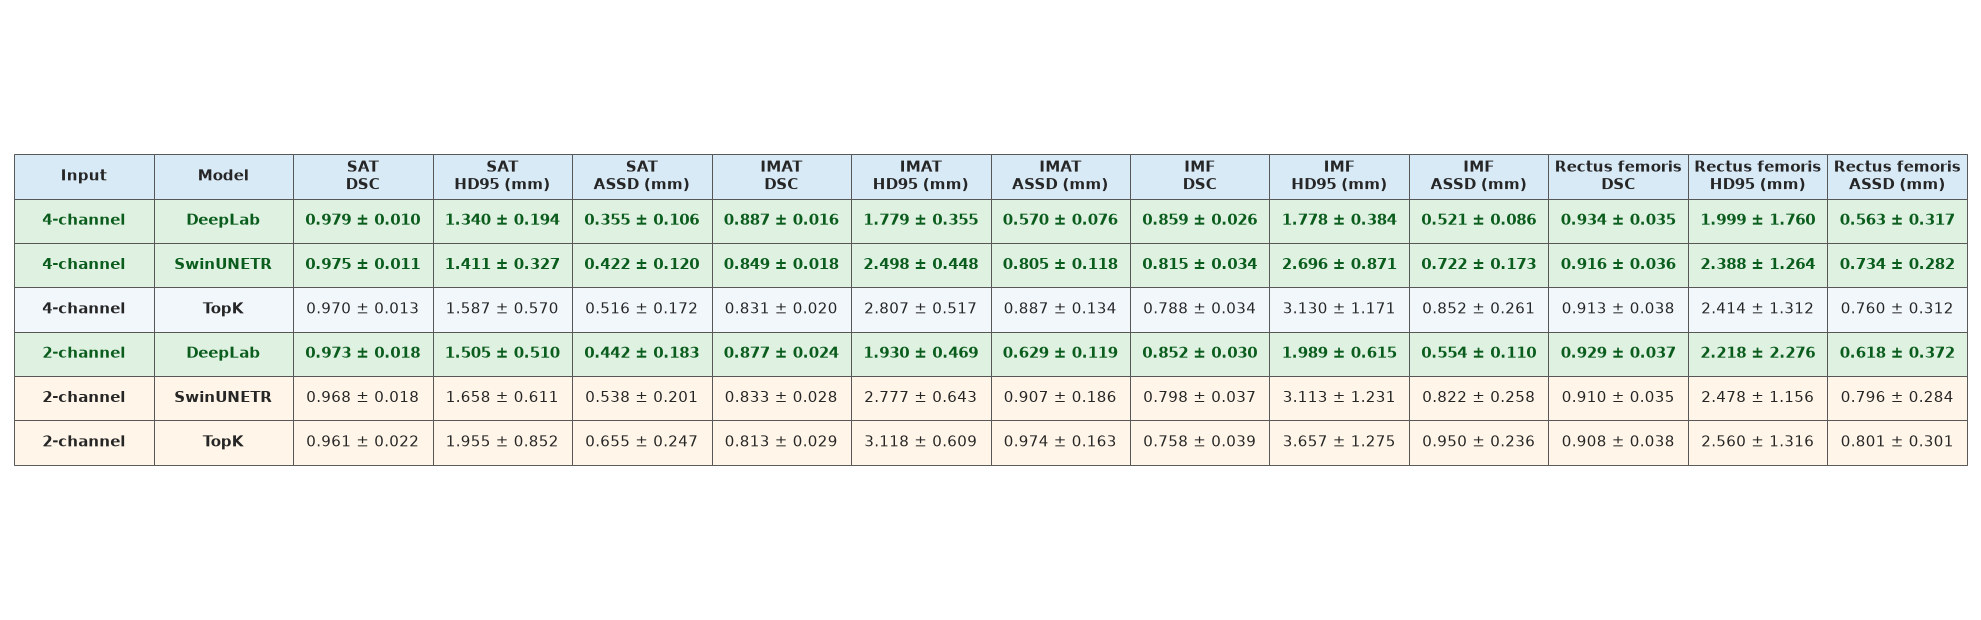

In [4]:
# Render the table as a high-resolution figure so it is visible in every notebook viewer.
flat_columns = ['Input', 'Model'] + [f'{label}\n{metric}' for label in label_order
                                    for metric, _ in metric_columns]
cell_rows = []
for channels, model in row_index:
    cell_rows.append([channels, model] + publication.loc[(channels, model)].tolist())

fig, ax = plt.subplots(figsize=(18, 5.5))
ax.axis('off')
table = ax.table(cellText=cell_rows, colLabels=flat_columns, cellLoc='center',
                 colLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(7.5)
table.scale(1, 1.9)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#555555')
    cell.set_linewidth(0.5)
    if row == 0:
        cell.set_facecolor('#D9EAF7')
        cell.set_text_props(weight='bold')
    elif cell_rows[row - 1][0] == '4-channel':
        cell.set_facecolor('#F2F7FC')
    else:
        cell.set_facecolor('#FFF5E8')
    if col in (0, 1) and row > 0:
        cell.set_text_props(weight='bold')
    if row > 0 and tuple(cell_rows[row - 1][:2]) in top_three:
        cell.set_facecolor('#DFF2E1')
        cell.set_text_props(weight='bold', color='#0B5D1E')

fig.savefig(FIG_DIR / 'final_dice_hd95_assd_table.png', dpi=140, bbox_inches='tight')
plt.show()


## 3. Paired 2-channel minus 4-channel comparison

For the same scan and model, differences are calculated as **2-channel − 4-channel**. Positive Dice differences favour 2-channel; negative HD95 and ASSD differences favour 2-channel. Wilcoxon p-values test whether the paired median difference is zero.


In [5]:
selected = metrics[metrics.Label.isin(label_key.values())]
wide = selected.pivot(index=['Model', 'Scan', 'Label'], columns='Channels',
                      values=['Dice', 'HD95_mm', 'ASSD_mm'])
rows = []
reverse_label = {value: key for key, value in label_key.items()}
for model in model_order:
    for label in label_key.values():
        for metric in ['Dice', 'HD95_mm', 'ASSD_mm']:
            values = (wide.loc[(model, slice(None), label), (metric, '2-channel')].to_numpy() -
                      wide.loc[(model, slice(None), label), (metric, '4-channel')].to_numpy())
            p = 1.0 if np.allclose(values, 0) else wilcoxon(values).pvalue
            rows.append({'Model': model, 'Label': reverse_label[label], 'Metric': metric,
                         'N': len(values), 'Mean_difference': values.mean(),
                         'SD_difference': values.std(ddof=1),
                         'Median_difference': np.median(values), 'Wilcoxon_p': p})
paired_tests = pd.DataFrame(rows)
paired_tests.to_csv(DATA_DIR / 'final_paired_2ch_minus_4ch_tests.csv', index=False)
paired_tests.round(5)


,Model,Label,Metric,N,Mean_difference,SD_difference,Median_difference,Wilcoxon_p
0,DeepLab,SAT,Dice,48,-0.00597,0.01054,-0.00260,0.00000
1,DeepLab,SAT,HD95_mm,48,0.16582,0.49031,0.00000,0.01776
2,DeepLab,SAT,ASSD_mm,48,0.08748,0.11716,0.04875,0.00000
3,DeepLab,IMAT,Dice,48,-0.01076,0.01473,-0.00665,0.00000
4,DeepLab,IMAT,HD95_mm,48,0.15094,0.34432,0.00000,0.00491
5,DeepLab,IMAT,ASSD_mm,48,0.05850,0.07041,0.04225,0.00000
6,DeepLab,IMF,Dice,48,-0.00660,0.01153,-0.00440,0.00000
7,DeepLab,IMF,HD95_mm,48,0.21041,0.44889,0.00000,0.00011
8,DeepLab,IMF,ASSD_mm,48,0.03347,0.06932,0.02210,0.00000
9,DeepLab,Rectus femoris,Dice,48,-0.00481,0.00650,-0.00347,0.00000


## 4. Metric distributions

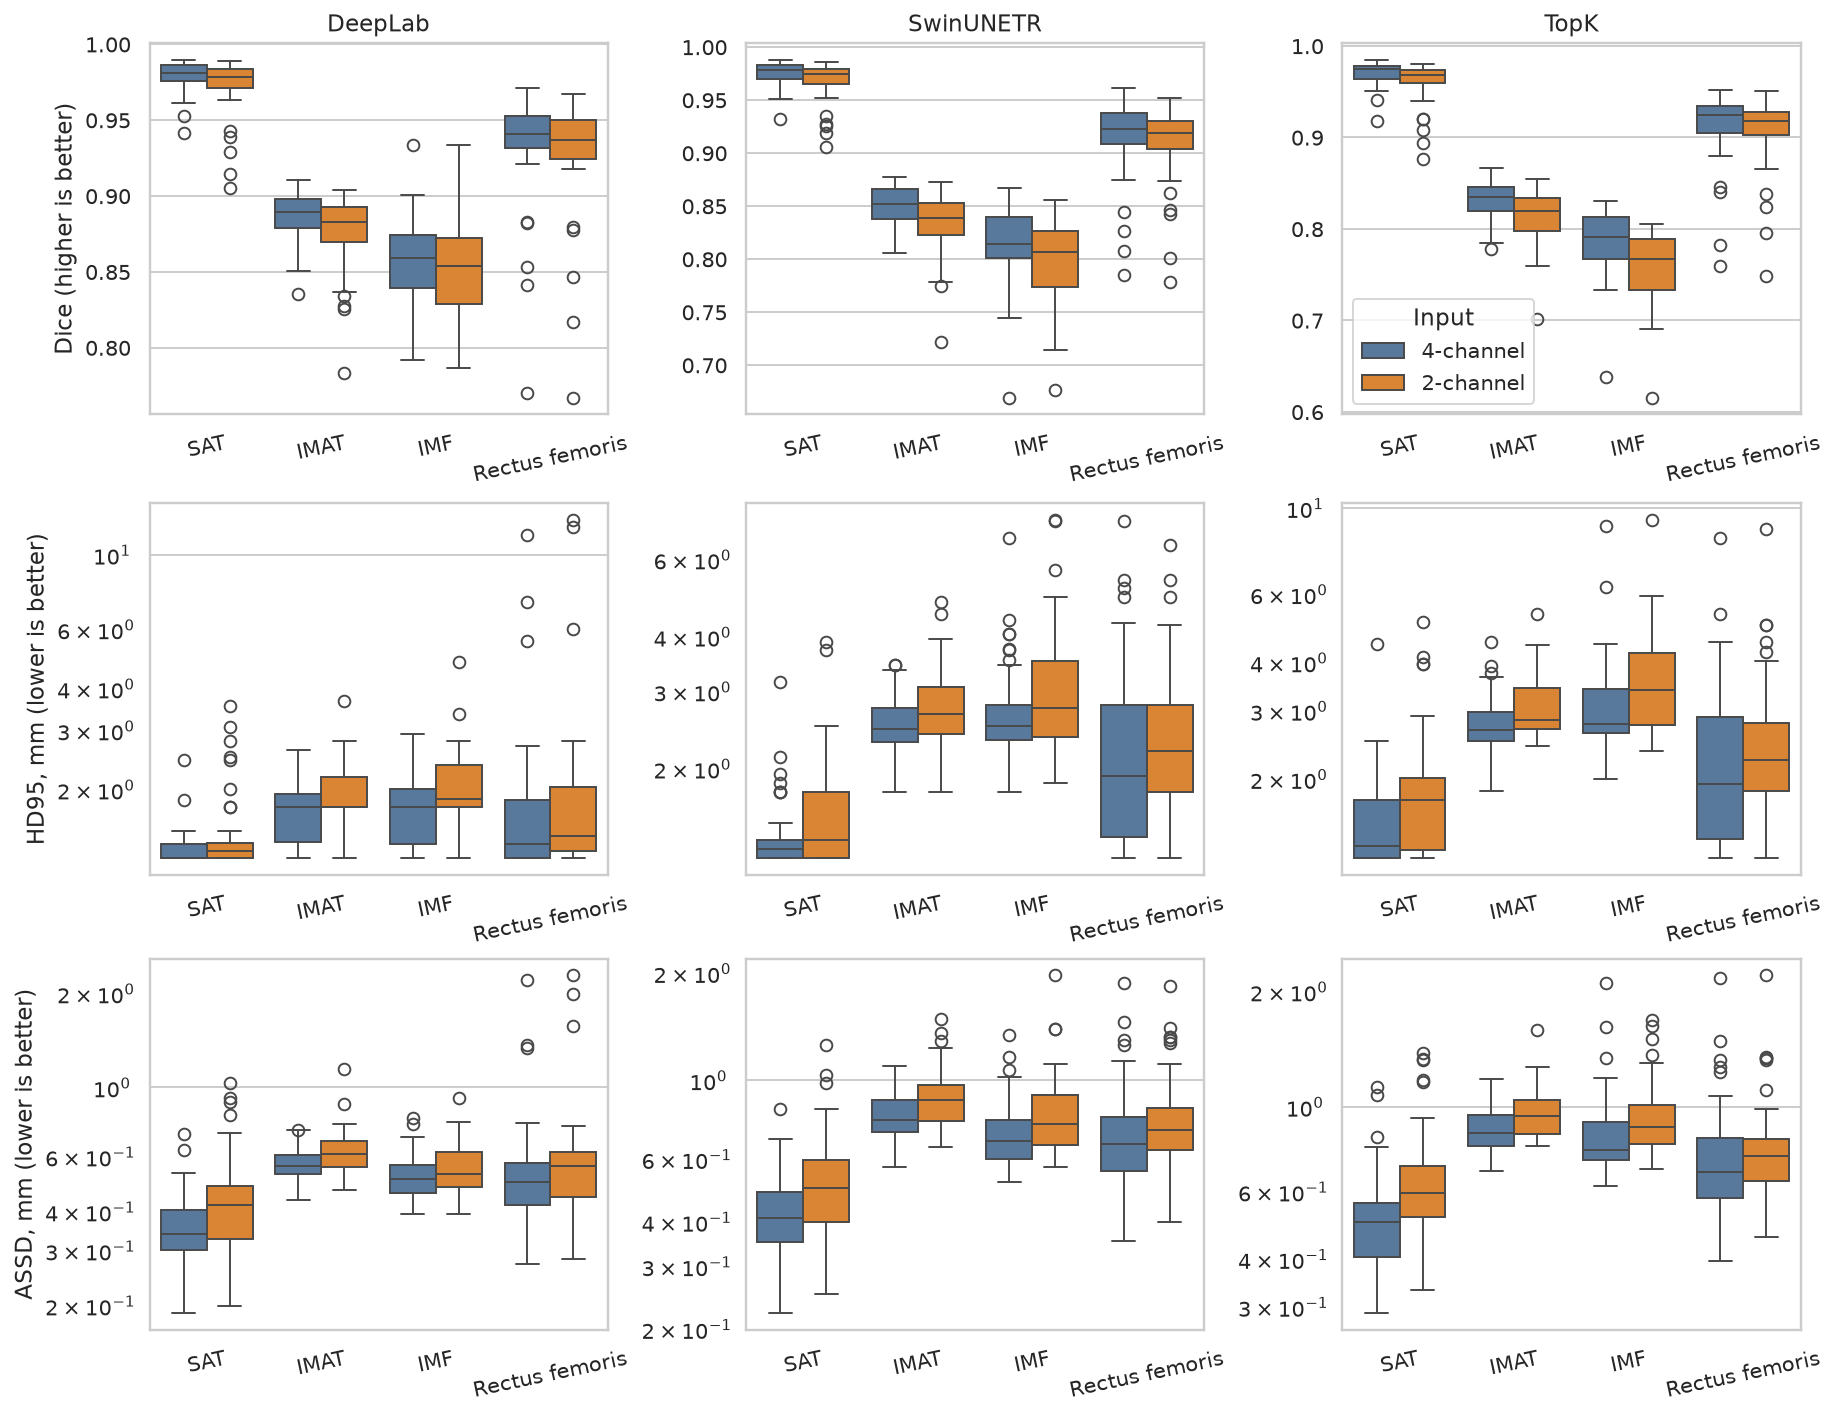

In [6]:
plot_data = metrics[metrics.Label.isin(label_key.values())].copy()
plot_data['Display_label'] = plot_data.Label.map(reverse_label)
specs = [('Dice', 'Dice (higher is better)', False),
         ('HD95_mm', 'HD95, mm (lower is better)', True),
         ('ASSD_mm', 'ASSD, mm (lower is better)', True)]
fig, axes = plt.subplots(3, 3, figsize=(13, 10), constrained_layout=True)
for row, (metric, ylabel, use_log) in enumerate(specs):
    for col, model in enumerate(model_order):
        ax = axes[row, col]
        subset = plot_data[plot_data.Model.eq(model)]
        sns.boxplot(data=subset, x='Display_label', y=metric, hue='Channels',
                    order=['SAT', 'IMAT', 'IMF', 'Rectus femoris'],
                    hue_order=channel_order, palette=['#4C78A8', '#F58518'],
                    showfliers=True, ax=ax)
        if use_log: ax.set_yscale('log')
        ax.set_title(model if row == 0 else '')
        ax.set_xlabel('')
        ax.set_ylabel(ylabel if col == 0 else '')
        ax.tick_params(axis='x', rotation=12)
        if row == 0 and col == 2: ax.legend(title='Input')
        else: ax.get_legend().remove()
fig.savefig(FIG_DIR / 'final_metric_distributions.png', dpi=130, bbox_inches='tight')
plt.show()


## 5. Correlation plots

Correlation figures are shown separately from Bland–Altman figures.

*4-channel · DeepLab · ground truth versus prediction*

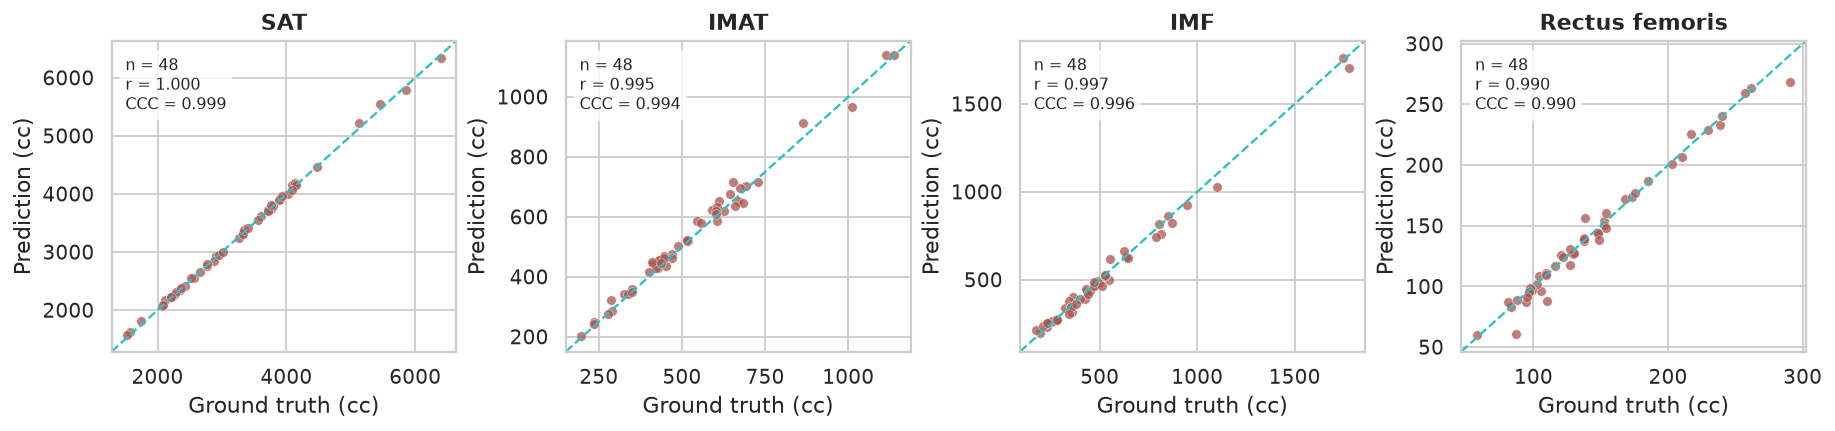

*4-channel · SwinUNETR · ground truth versus prediction*

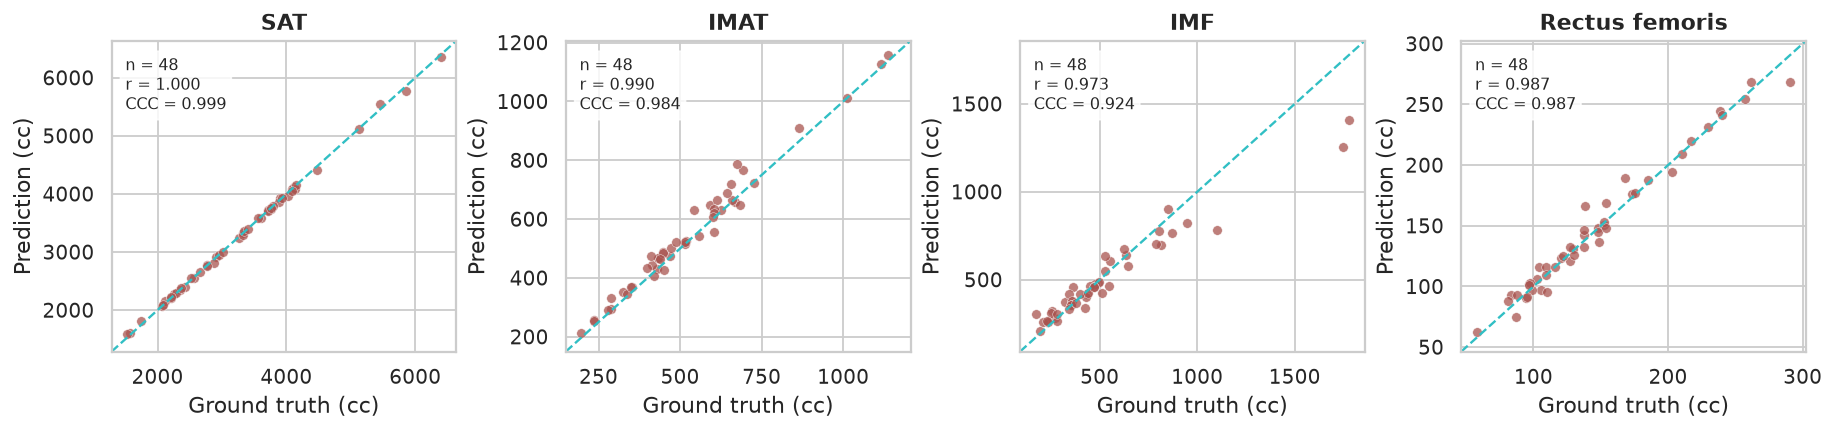

*4-channel · TopK · ground truth versus prediction*

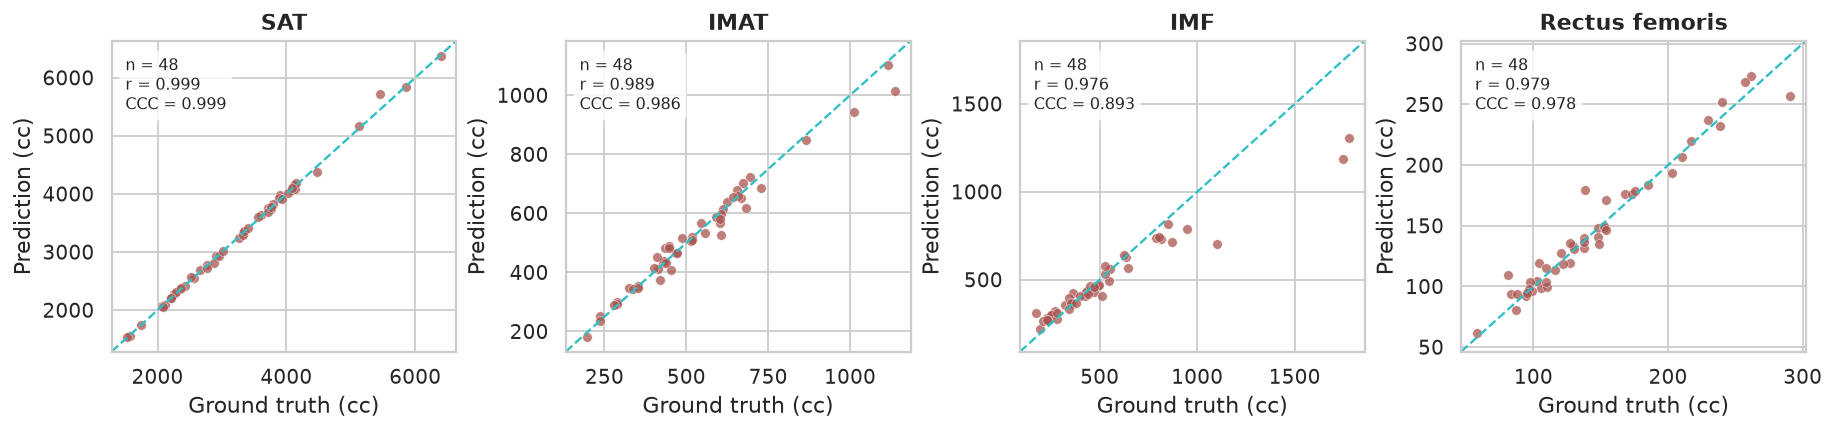

*2-channel · DeepLab · ground truth versus prediction*

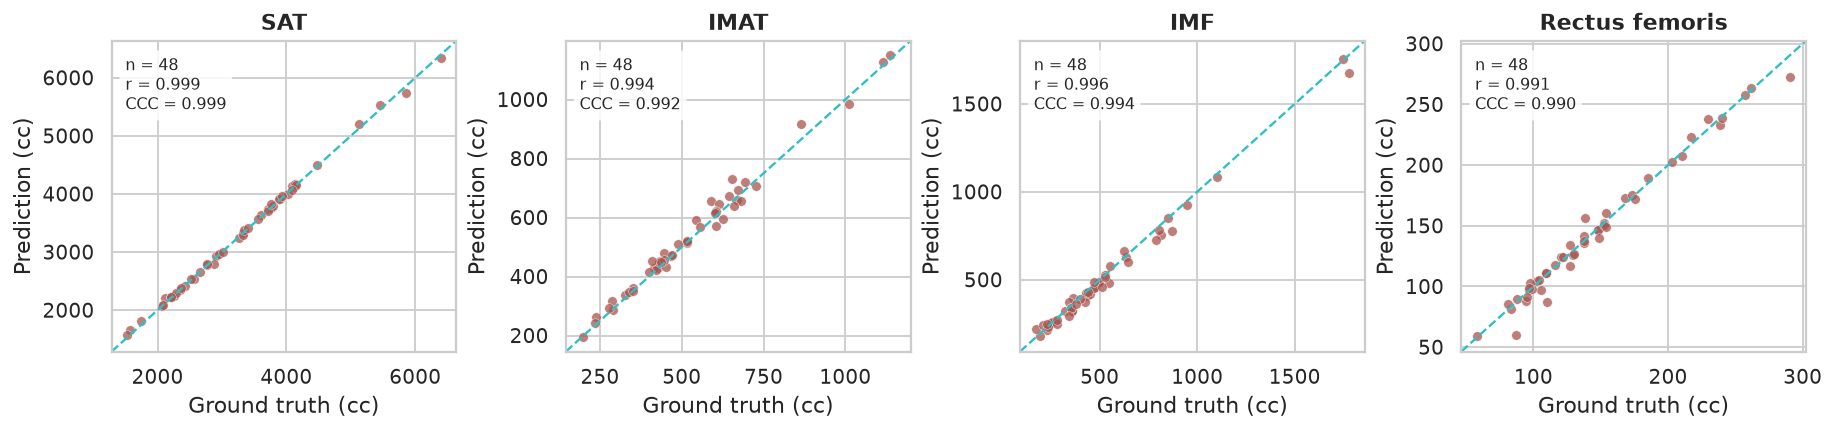

*2-channel · SwinUNETR · ground truth versus prediction*

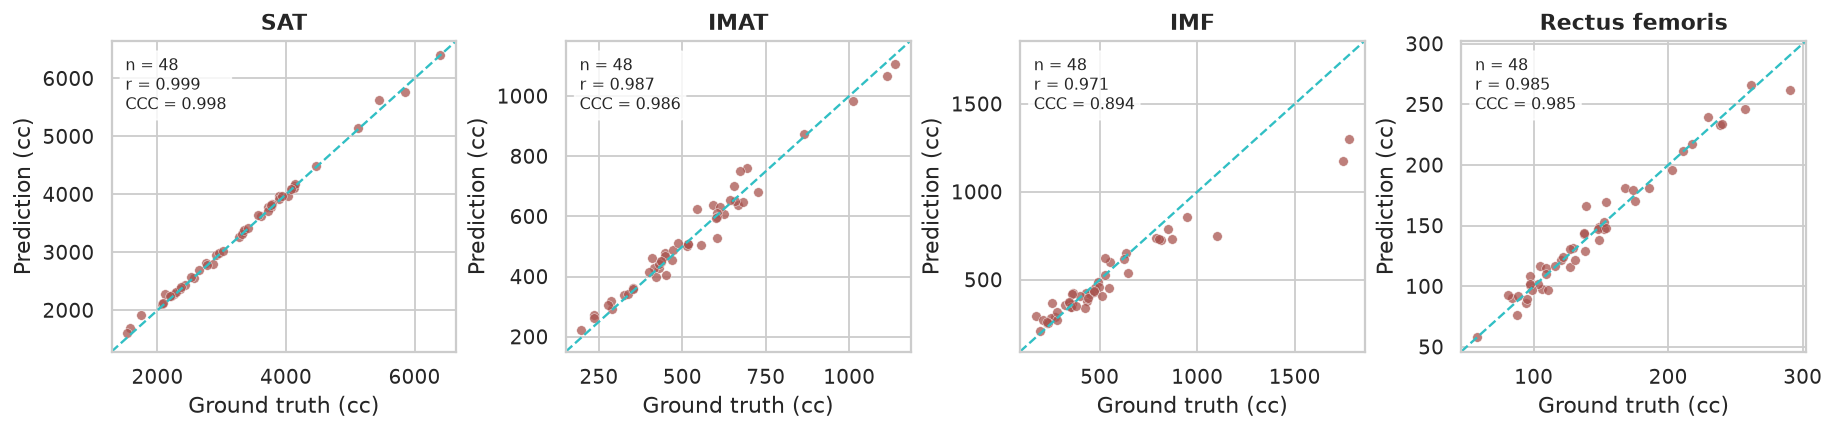

*2-channel · TopK · ground truth versus prediction*

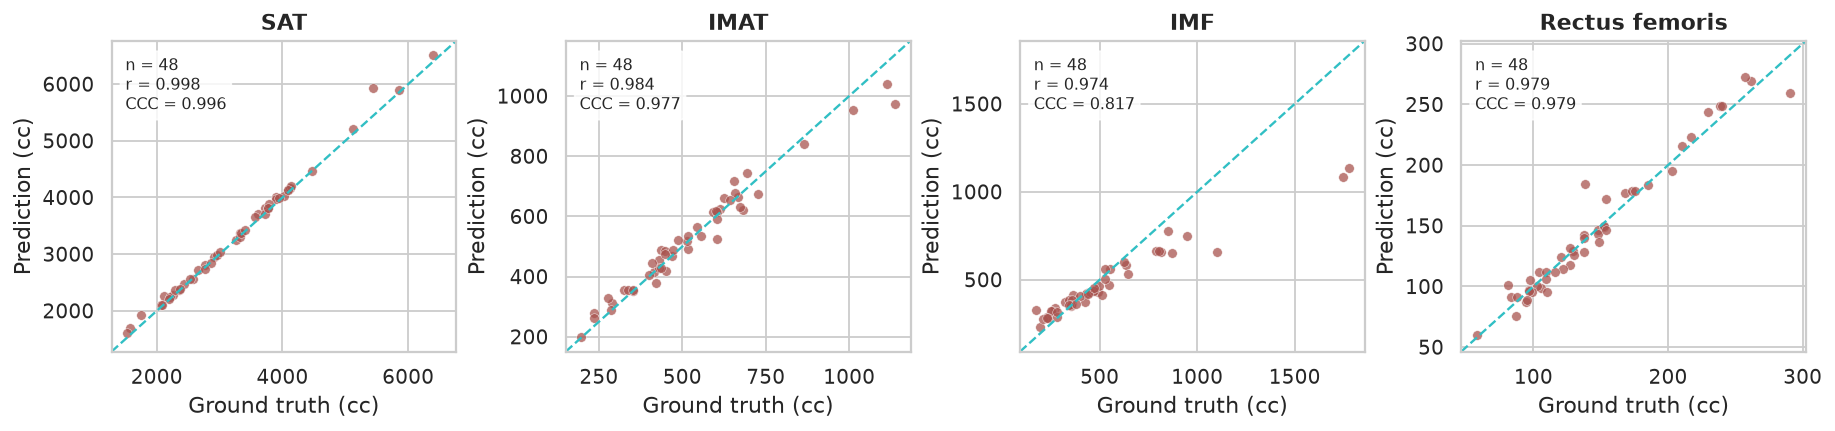

*DeepLab · direct 2-channel versus 4-channel*

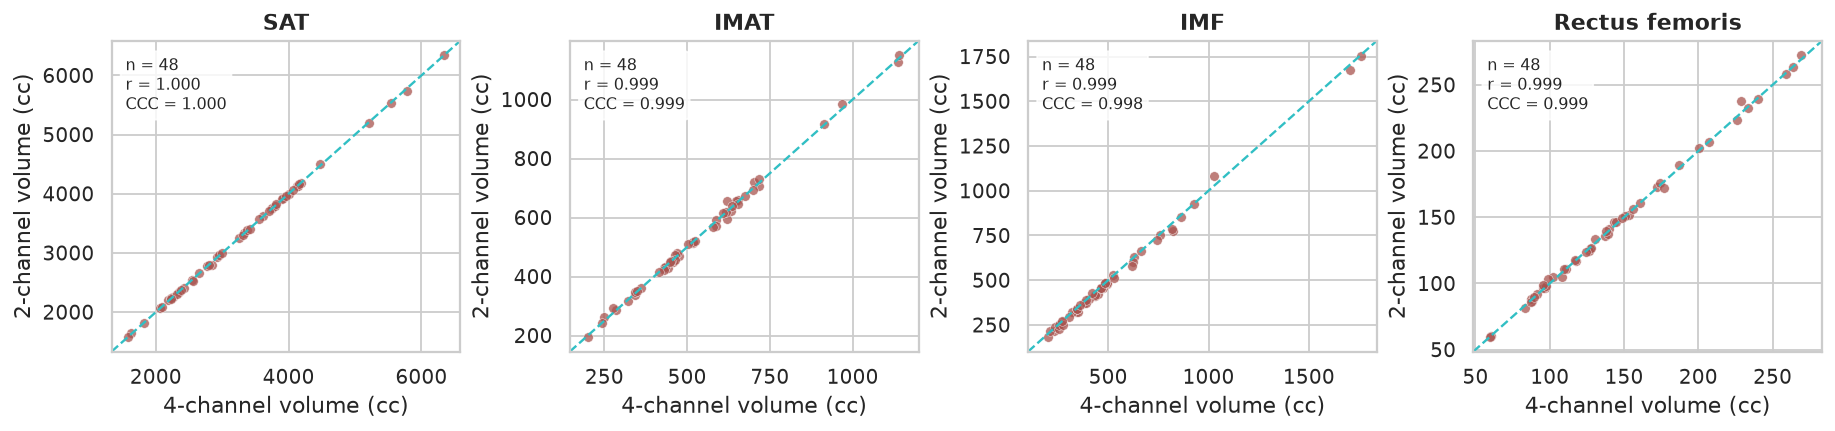

*SwinUNETR · direct 2-channel versus 4-channel*

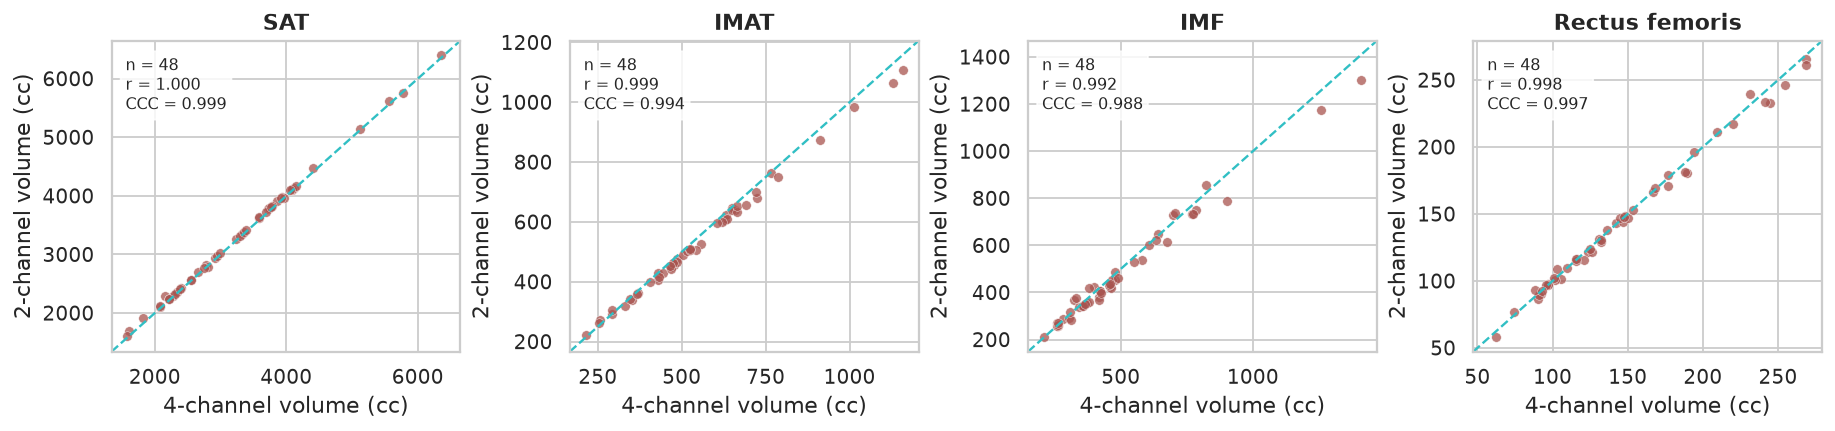

*TopK · direct 2-channel versus 4-channel*

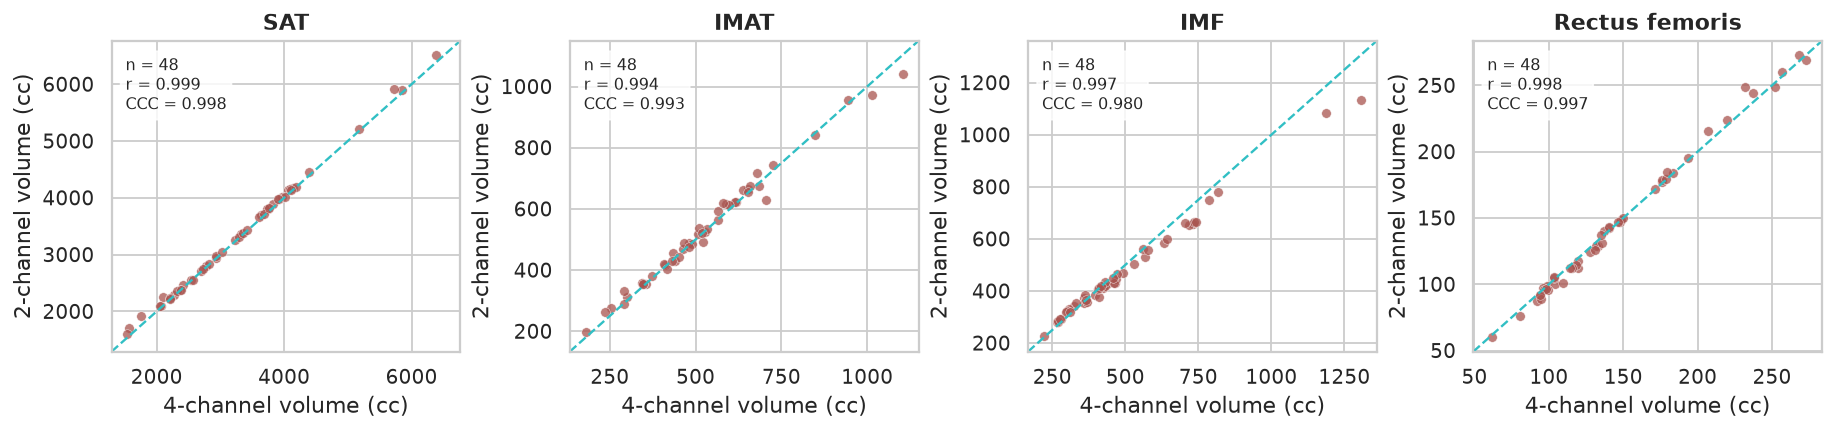



In [7]:
volume_data = metrics[metrics.Label.isin(label_key.values())].copy()
volume_data['Display_label'] = volume_data.Label.map(reverse_label)

def concordance_correlation(x, y):
    x, y = np.asarray(x), np.asarray(y)
    return (2 * np.cov(x, y, ddof=1)[0, 1] /
            (np.var(x, ddof=1) + np.var(y, ddof=1) + (x.mean() - y.mean())**2))

gt_volume_rows = []
for (channels, model, label), group in volume_data.groupby(['Channels', 'Model', 'Display_label']):
    x = group.GT_Volume_cc.to_numpy()
    y = group.Prediction_Volume_cc.to_numpy()
    difference = y - x
    bias, sd = difference.mean(), difference.std(ddof=1)
    r, p = pearsonr(x, y)
    gt_volume_rows.append({
        'Channels': channels, 'Model': model, 'Label': label, 'N': len(group),
        'Pearson_r': r, 'Pearson_p': p, 'CCC': concordance_correlation(x, y),
        'Mean_bias_prediction_minus_GT_cc': bias,
        'Lower_95pct_LoA_cc': bias - 1.96*sd,
        'Upper_95pct_LoA_cc': bias + 1.96*sd,
        'MAE_cc': np.abs(difference).mean(),
        'RMSE_cc': np.sqrt(np.mean(difference**2)),
    })
gt_volume_stats = pd.DataFrame(gt_volume_rows).sort_values(['Channels', 'Model', 'Label'])
gt_volume_stats.to_csv(DATA_DIR / 'final_ground_truth_volume_agreement.csv', index=False)
gt_volume_stats.round(4)


,Channels,Model,Label,N,Pearson_r,Pearson_p,CCC,Mean_bias_prediction_minus_GT_cc,Lower_95pct_LoA_cc,Upper_95pct_LoA_cc,MAE_cc,RMSE_cc
0,2-channel,DeepLab,IMAT,48,0.9938,0.0,0.9923,11.2965,-33.6928,56.2859,19.6075,25.3675
1,2-channel,DeepLab,IMF,48,0.9961,0.0,0.9944,-15.7705,-77.1533,45.6123,26.1241,34.7718
2,2-channel,DeepLab,Rectus femoris,48,0.9906,0.0,0.9903,-1.0115,-15.6971,13.6741,4.8612,7.4829
3,2-channel,DeepLab,SAT,48,0.9994,0.0,0.9993,11.1402,-64.8613,87.1418,29.4127,39.9547
4,2-channel,SwinUNETR,IMAT,48,0.9874,0.0,0.9861,5.6741,-59.4403,70.7885,26.2769,33.3599
5,2-channel,SwinUNETR,IMF,48,0.9710,0.0,0.8940,-37.0632,-287.3028,213.1764,72.7580,131.6607
6,2-channel,SwinUNETR,Rectus femoris,48,0.9854,0.0,0.9848,-0.1673,-18.3562,18.0217,6.8807,9.1844
7,2-channel,SwinUNETR,SAT,48,0.9989,0.0,0.9984,30.3469,-71.5650,132.2589,42.1666,59.7343
8,2-channel,TopK,IMAT,48,0.9841,0.0,0.9774,0.3560,-80.9418,81.6537,29.7800,41.0457
9,2-channel,TopK,IMF,48,0.9741,0.0,0.8168,-51.0280,-362.1507,260.0947,88.6755,165.1547


In [8]:
def ground_truth_correlation_figure(channels, model):
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
    for col, display_label in enumerate(label_order):
        group = volume_data[(volume_data.Channels.eq(channels)) &
                            (volume_data.Model.eq(model)) &
                            (volume_data.Display_label.eq(display_label))]
        gt = group.GT_Volume_cc.to_numpy()
        prediction = group.Prediction_Volume_cc.to_numpy()
        r = pearsonr(gt, prediction).statistic
        ccc = concordance_correlation(gt, prediction)
        lo, hi = min(gt.min(), prediction.min()), max(gt.max(), prediction.max())
        pad = max((hi-lo)*0.05, 1)

        ax = axes[col]
        ax.scatter(gt, prediction, color='#A8544F', alpha=0.75, s=28,
                    edgecolor='white', linewidth=0.3)
        ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], '--', color='#31BFC4', linewidth=1.3)
        ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
        ax.set_title(display_label, fontweight='bold')
        ax.set_xlabel('Ground truth (cc)')
        ax.set_ylabel('Prediction (cc)')
        ax.text(0.04, 0.95, f'n = {len(group)}\nr = {r:.3f}\nCCC = {ccc:.3f}',
                 transform=ax.transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.82))
    slug = f'{channels.replace("-", "")}_{model.lower()}'
    fig.savefig(FIG_DIR / f'final_gt_corr_{slug}.png', dpi=130, bbox_inches='tight')
    plt.close(fig)

for channels in channel_order:
    for model in model_order:
        ground_truth_correlation_figure(channels, model)


### Direct 2-channel versus 4-channel statistics

These comparisons pair predictions for the same scan and model.


In [9]:
channel_wide = (volume_data.pivot(index=['Model', 'Scan', 'Display_label'],
                                  columns='Channels', values='Prediction_Volume_cc')
                .dropna().reset_index().rename_axis(None, axis=1))
channel_rows = []
for (model, label), group in channel_wide.groupby(['Model', 'Display_label']):
    x, y = group['4-channel'].to_numpy(), group['2-channel'].to_numpy()
    difference = y - x
    bias, sd = difference.mean(), difference.std(ddof=1)
    r, p = pearsonr(x, y)
    channel_rows.append({
        'Model': model, 'Label': label, 'N': len(group), 'Pearson_r': r,
        'Pearson_p': p, 'CCC': concordance_correlation(x, y),
        'Mean_bias_2ch_minus_4ch_cc': bias,
        'Lower_95pct_LoA_cc': bias - 1.96*sd,
        'Upper_95pct_LoA_cc': bias + 1.96*sd,
    })
channel_volume_stats = pd.DataFrame(channel_rows).sort_values(['Model', 'Label'])
channel_volume_stats.to_csv(DATA_DIR / 'final_2ch_vs_4ch_volume_agreement.csv', index=False)
channel_volume_stats.round(4)


,Model,Label,N,Pearson_r,Pearson_p,CCC,Mean_bias_2ch_minus_4ch_cc,Lower_95pct_LoA_cc,Upper_95pct_LoA_cc
0,DeepLab,IMAT,48,0.9988,0.0,0.9988,0.4734,-19.4573,20.4042
1,DeepLab,IMF,48,0.9988,0.0,0.9984,-9.9883,-40.9354,20.9589
2,DeepLab,Rectus femoris,48,0.9992,0.0,0.9991,0.4639,-3.9579,4.8858
3,DeepLab,SAT,48,0.9999,0.0,0.9999,-1.6123,-34.0551,30.8306
4,SwinUNETR,IMAT,48,0.9988,0.0,0.9938,-16.7547,-46.9398,13.4305
5,SwinUNETR,IMF,48,0.9924,0.0,0.9877,-15.1639,-81.7271,51.3993
6,SwinUNETR,Rectus femoris,48,0.9976,0.0,0.9970,-1.3762,-8.9499,6.1974
7,SwinUNETR,SAT,48,0.9997,0.0,0.9992,32.9409,-18.8311,84.7129
8,TopK,IMAT,48,0.9940,0.0,0.9926,4.8194,-39.0292,48.6681
9,TopK,IMF,48,0.9972,0.0,0.9798,-17.7926,-91.4919,55.9067


In [10]:
def channel_correlation_figure(model):
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
    for col, display_label in enumerate(label_order):
        group = channel_wide[(channel_wide.Model.eq(model)) &
                             (channel_wide.Display_label.eq(display_label))]
        four = group['4-channel'].to_numpy()
        two = group['2-channel'].to_numpy()
        r = pearsonr(four, two).statistic
        ccc = concordance_correlation(four, two)
        lo, hi = min(four.min(), two.min()), max(four.max(), two.max())
        pad = max((hi-lo)*0.05, 1)

        ax = axes[col]
        ax.scatter(four, two, color='#A8544F', alpha=0.75, s=28,
                    edgecolor='white', linewidth=0.3)
        ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], '--', color='#31BFC4', linewidth=1.3)
        ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
        ax.set_title(display_label, fontweight='bold')
        ax.set_xlabel('4-channel volume (cc)')
        ax.set_ylabel('2-channel volume (cc)')
        ax.text(0.04, 0.95, f'n = {len(group)}\nr = {r:.3f}\nCCC = {ccc:.3f}',
                 transform=ax.transAxes, va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.82))
    fig.savefig(FIG_DIR / f'final_channel_corr_{model.lower()}.png', dpi=130, bbox_inches='tight')
    plt.close(fig)

for model in model_order:
    channel_correlation_figure(model)


## 6. Bland–Altman plots

Bland–Altman figures are shown separately below.

*4-channel · DeepLab · prediction versus ground truth*

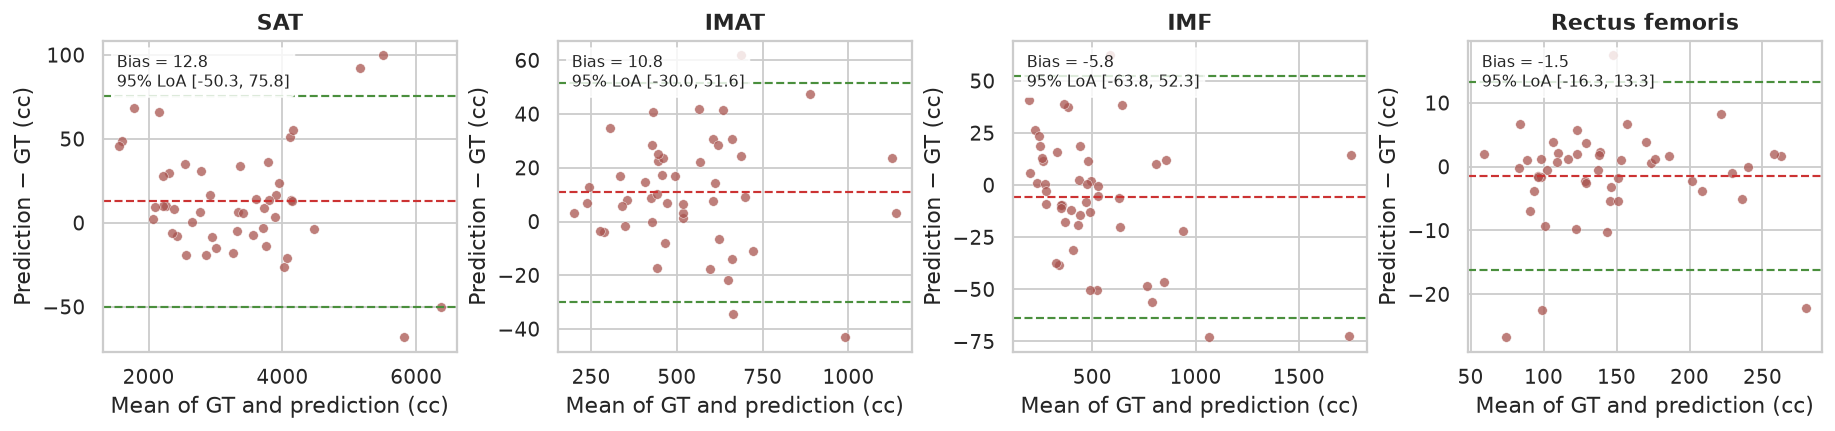

*4-channel · SwinUNETR · prediction versus ground truth*

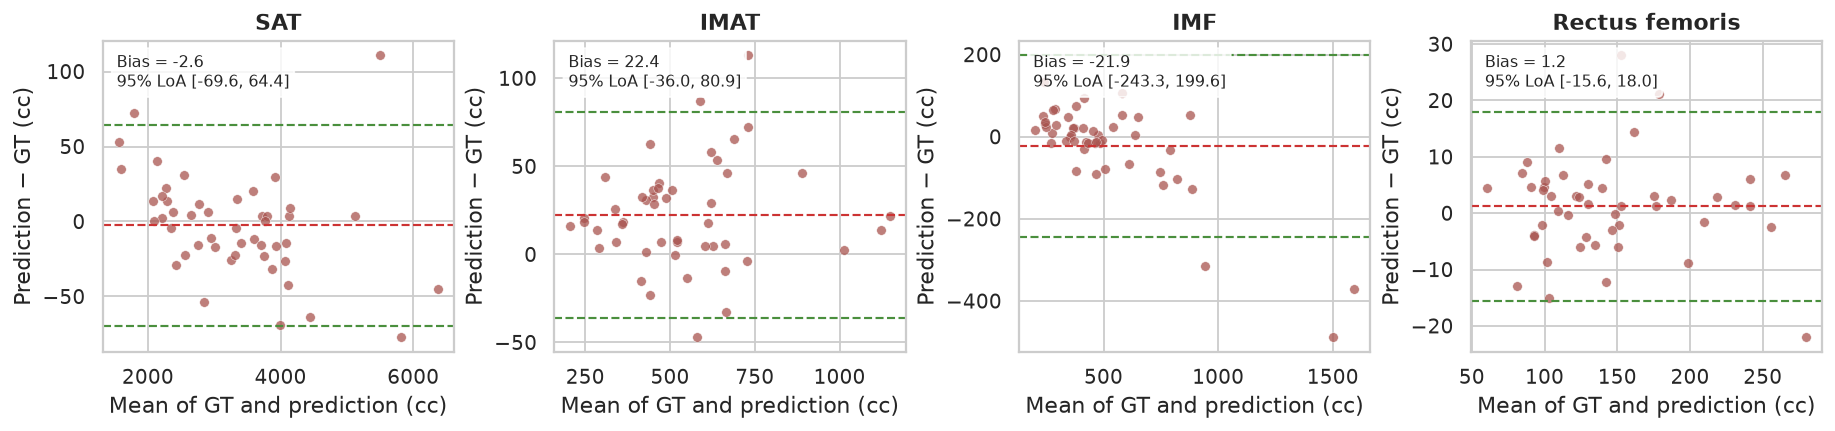

*4-channel · TopK · prediction versus ground truth*

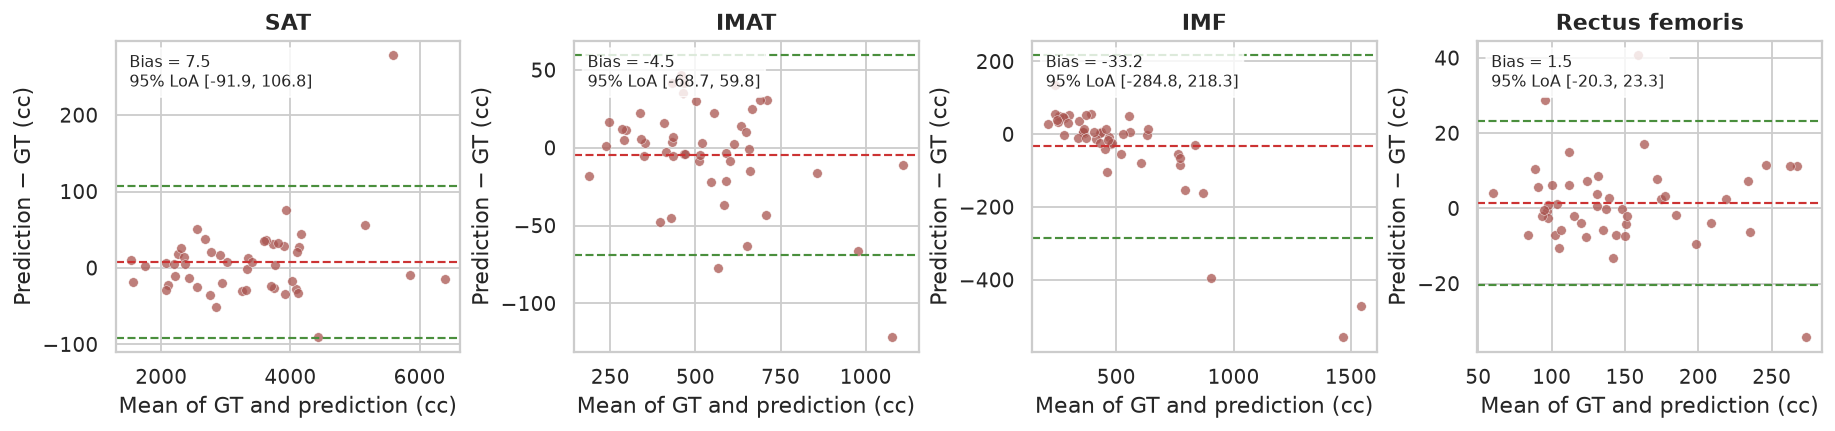

*2-channel · DeepLab · prediction versus ground truth*

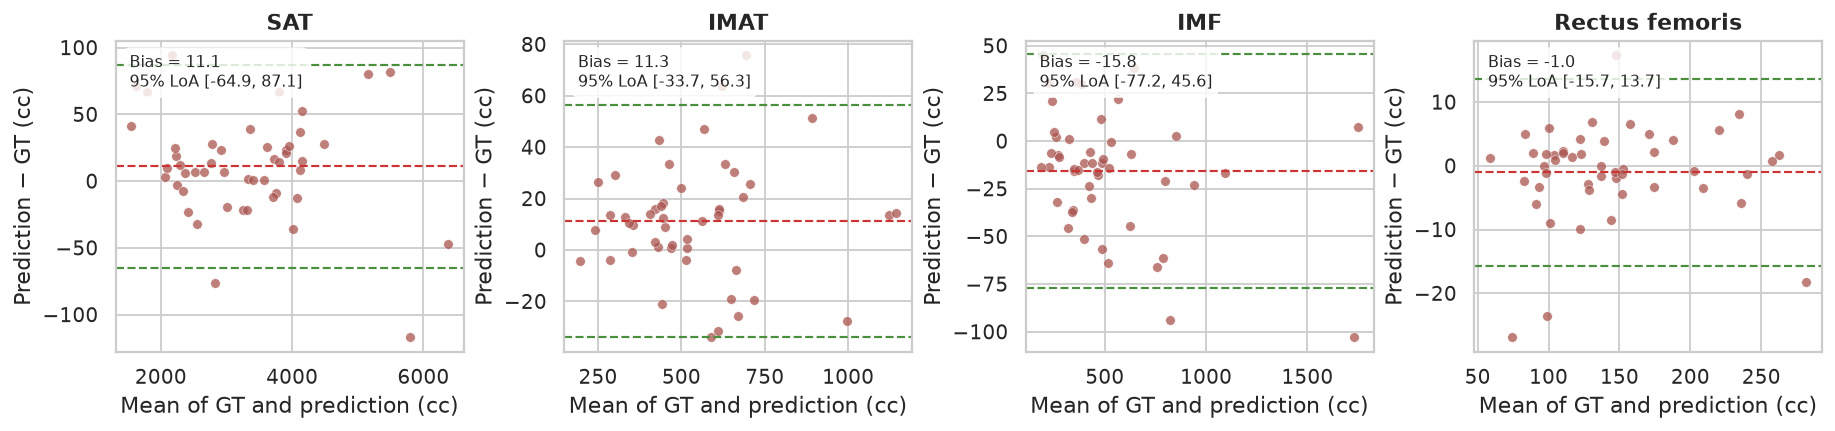

*2-channel · SwinUNETR · prediction versus ground truth*

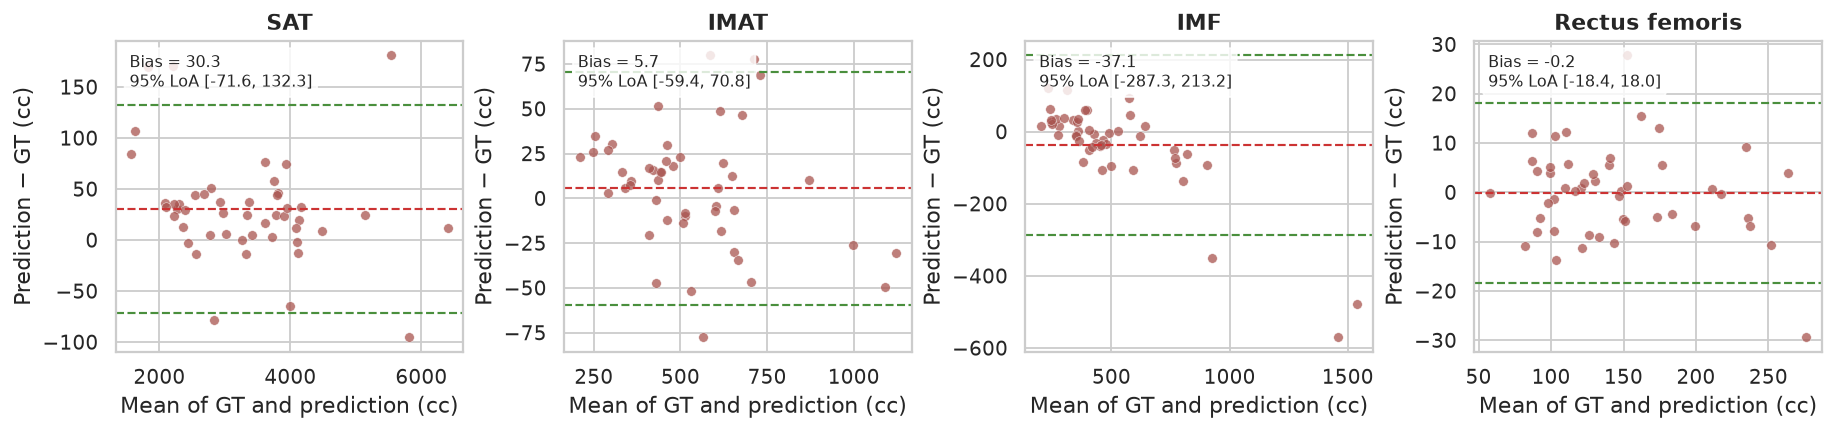

*2-channel · TopK · prediction versus ground truth*

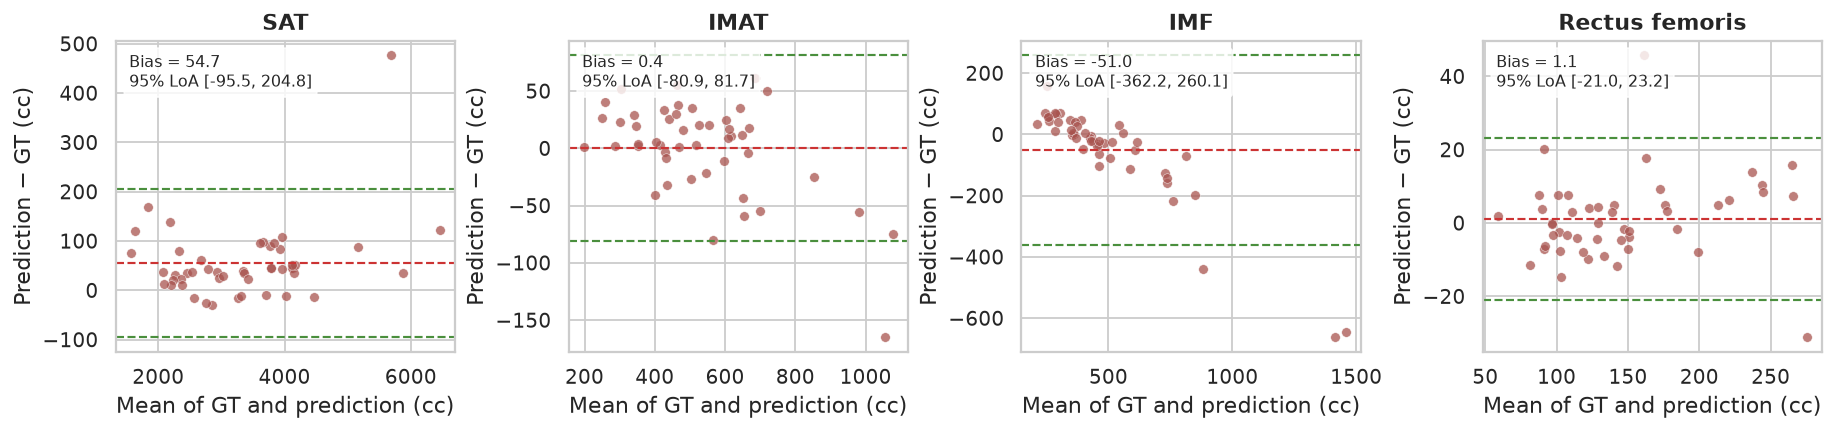

*DeepLab · direct 2-channel versus 4-channel*

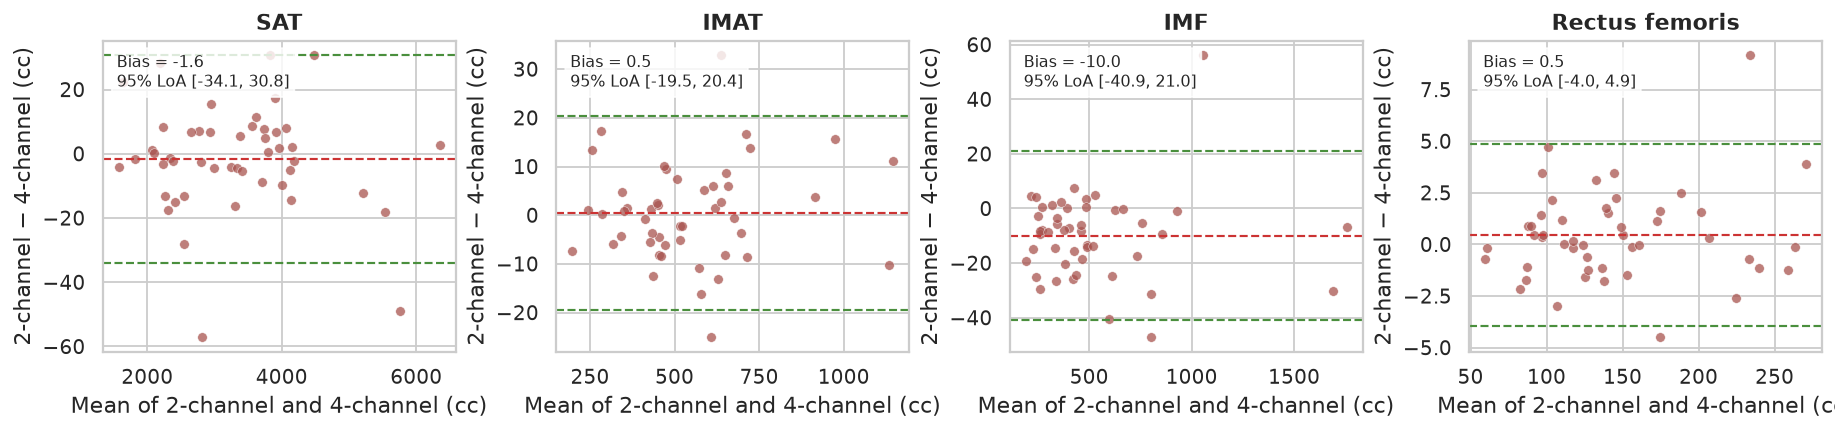

*SwinUNETR · direct 2-channel versus 4-channel*

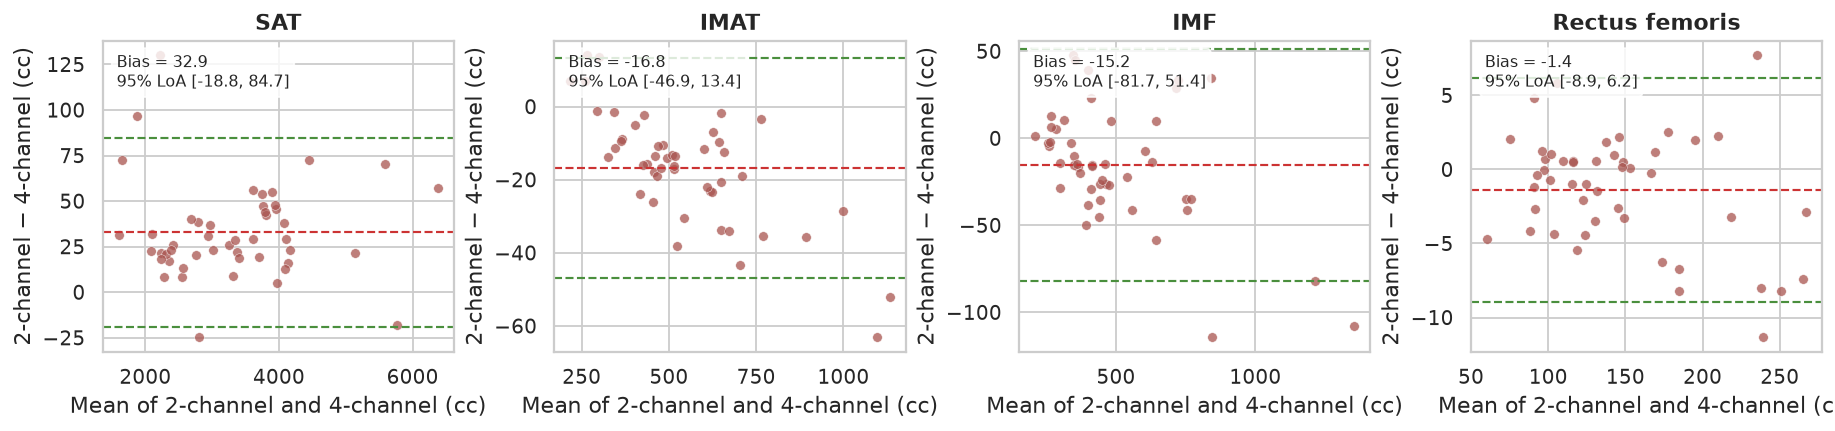

*TopK · direct 2-channel versus 4-channel*

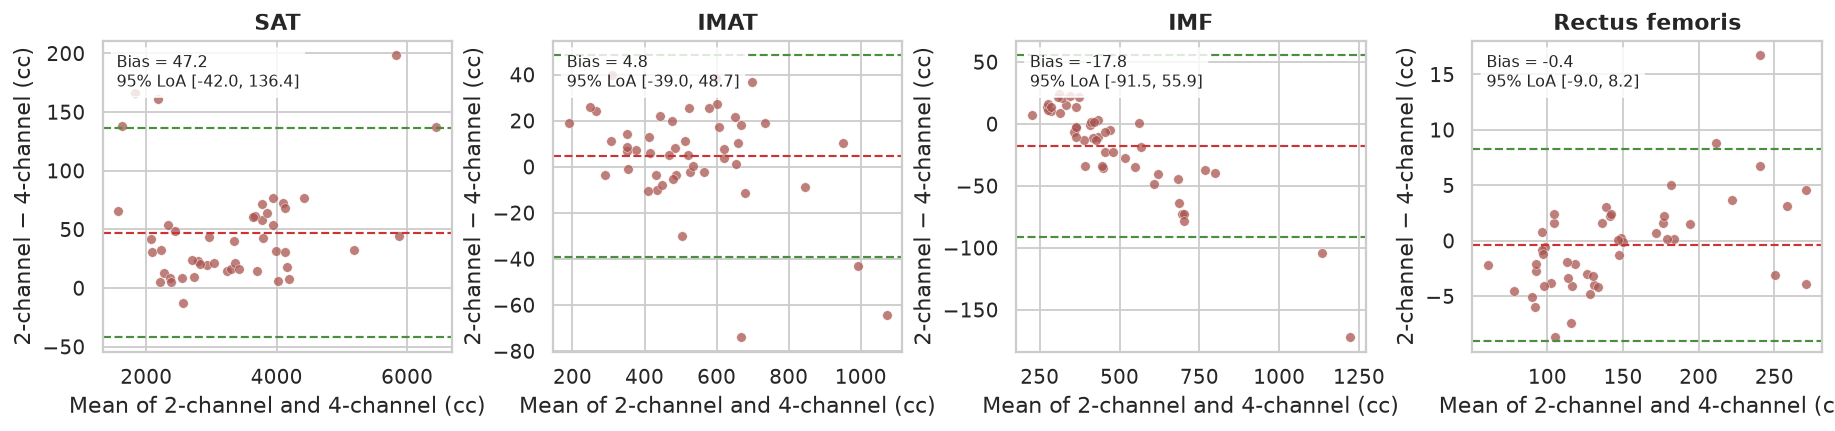



In [11]:
def ground_truth_bland_altman_figure(channels, model):
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
    for col, display_label in enumerate(label_order):
        group = volume_data[(volume_data.Channels.eq(channels)) &
                            (volume_data.Model.eq(model)) &
                            (volume_data.Display_label.eq(display_label))]
        gt = group.GT_Volume_cc.to_numpy()
        prediction = group.Prediction_Volume_cc.to_numpy()
        difference = prediction - gt
        mean_volume = (prediction + gt) / 2
        bias, sd = difference.mean(), difference.std(ddof=1)
        lower, upper = bias - 1.96*sd, bias + 1.96*sd
        ax = axes[col]
        ax.scatter(mean_volume, difference, color='#A8544F', alpha=0.75, s=28,
                   edgecolor='white', linewidth=0.3)
        ax.axhline(bias, color='#CC3333', linestyle='--', linewidth=1.2)
        ax.axhline(lower, color='#4A8F3D', linestyle='--', linewidth=1.2)
        ax.axhline(upper, color='#4A8F3D', linestyle='--', linewidth=1.2)
        ax.set_title(display_label, fontweight='bold')
        ax.set_xlabel('Mean of GT and prediction (cc)')
        ax.set_ylabel('Prediction − GT (cc)')
        ax.text(0.04, 0.96, f'Bias = {bias:.1f}\n95% LoA [{lower:.1f}, {upper:.1f}]',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.82))
    slug = f'{channels.replace("-", "")}_{model.lower()}'
    fig.savefig(FIG_DIR / f'final_gt_bland_{slug}.png', dpi=130, bbox_inches='tight')
    plt.close(fig)

def channel_bland_altman_figure(model):
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
    for col, display_label in enumerate(label_order):
        group = channel_wide[(channel_wide.Model.eq(model)) &
                             (channel_wide.Display_label.eq(display_label))]
        four = group['4-channel'].to_numpy()
        two = group['2-channel'].to_numpy()
        difference = two - four
        mean_volume = (two + four) / 2
        bias, sd = difference.mean(), difference.std(ddof=1)
        lower, upper = bias - 1.96*sd, bias + 1.96*sd
        ax = axes[col]
        ax.scatter(mean_volume, difference, color='#A8544F', alpha=0.75, s=28,
                   edgecolor='white', linewidth=0.3)
        ax.axhline(bias, color='#CC3333', linestyle='--', linewidth=1.2)
        ax.axhline(lower, color='#4A8F3D', linestyle='--', linewidth=1.2)
        ax.axhline(upper, color='#4A8F3D', linestyle='--', linewidth=1.2)
        ax.set_title(display_label, fontweight='bold')
        ax.set_xlabel('Mean of 2-channel and 4-channel (cc)')
        ax.set_ylabel('2-channel − 4-channel (cc)')
        ax.text(0.04, 0.96, f'Bias = {bias:.1f}\n95% LoA [{lower:.1f}, {upper:.1f}]',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.82))
    fig.savefig(FIG_DIR / f'final_channel_bland_{model.lower()}.png', dpi=130, bbox_inches='tight')
    plt.close(fig)

for channels in channel_order:
    for model in model_order:
        ground_truth_bland_altman_figure(channels, model)
for model in model_order:
    channel_bland_altman_figure(model)


## 7. Figures

The performance table and metric distribution figure are shown below.

*Publication-style Dice, HD95, and ASSD table*

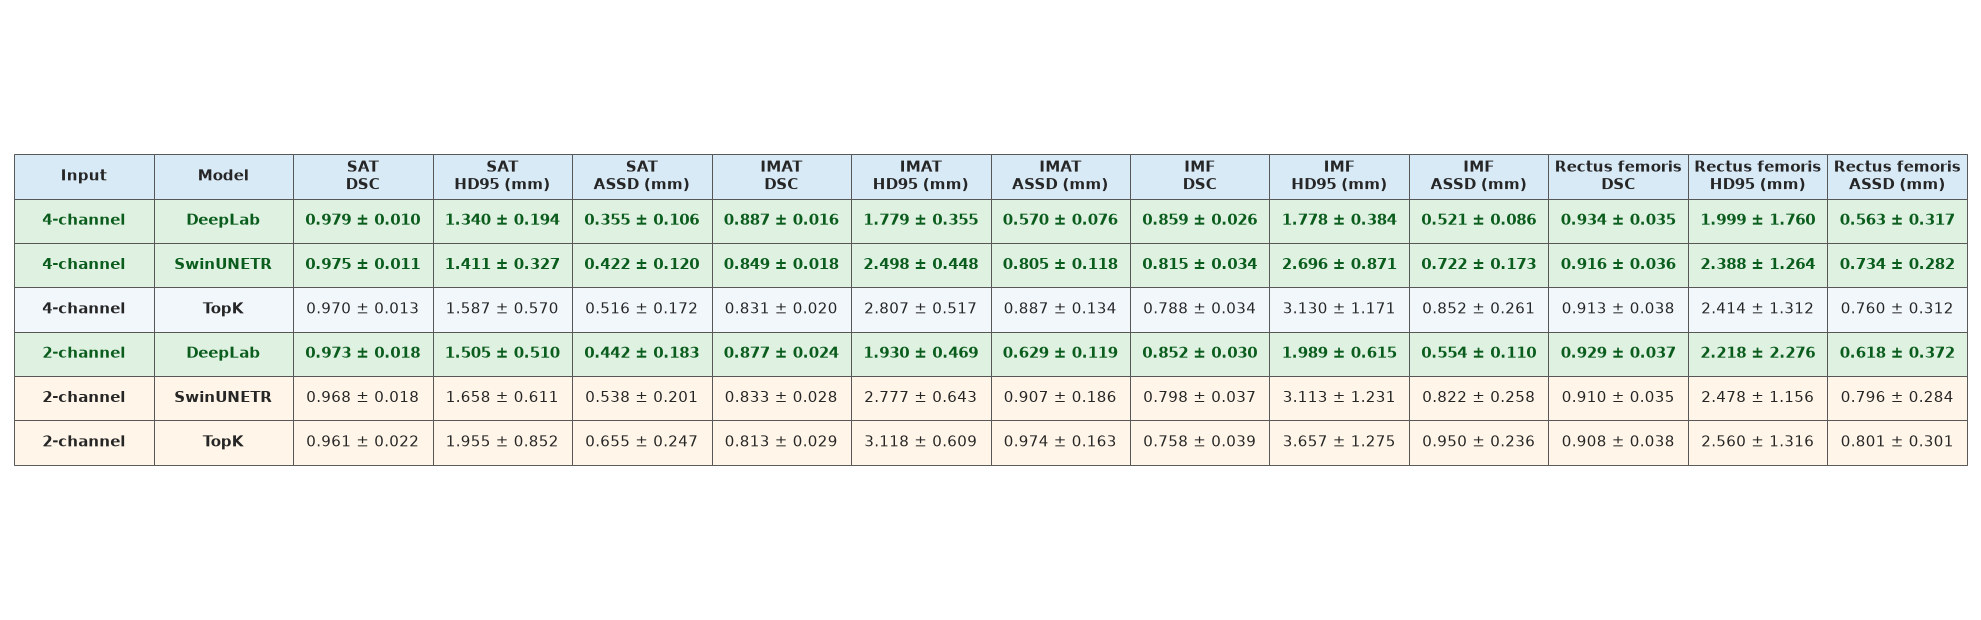

*Metric distributions*

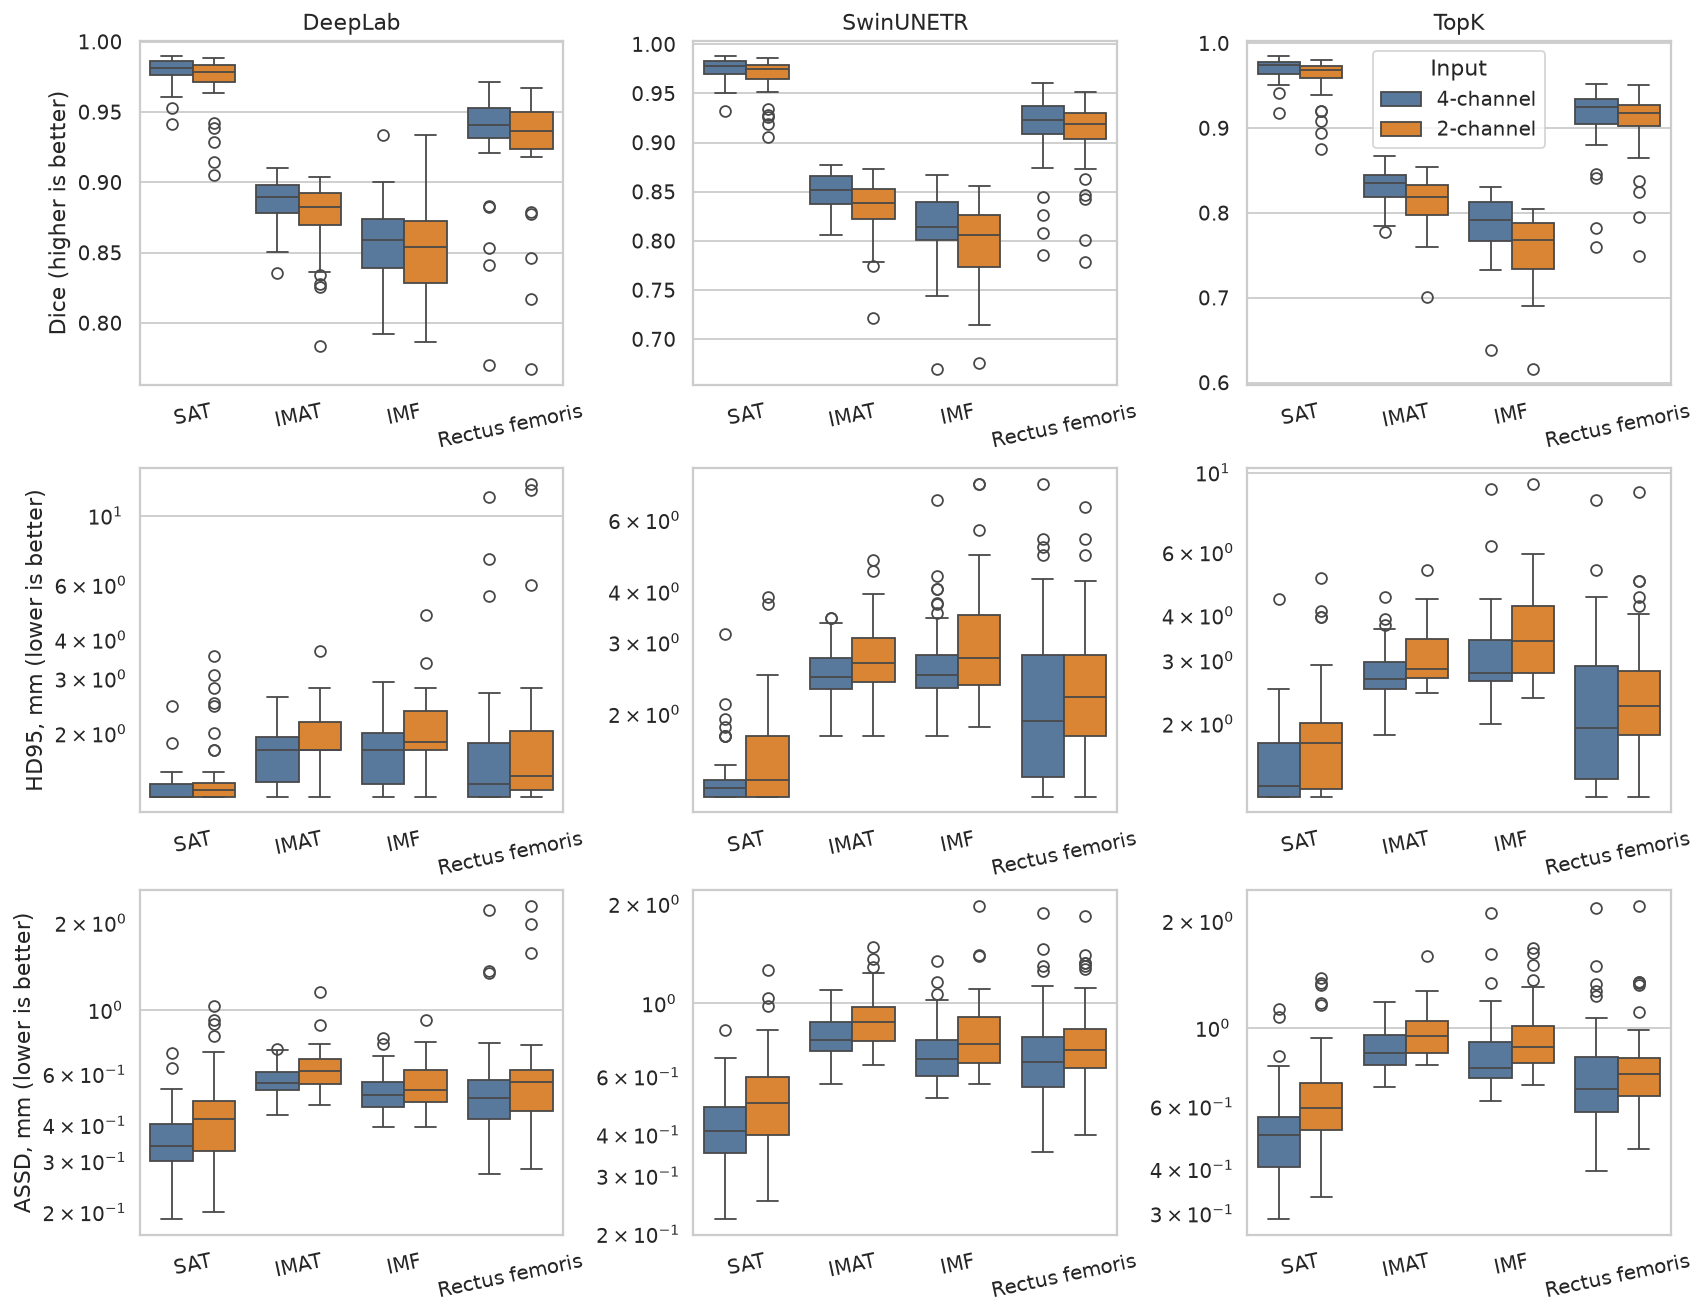



## 8. Notes

1. Dataset 709 is the 4-channel run; Dataset 710 is the 2-channel run.
2. Statistics use 48 cases having compatible Jordan ground truth and predictions in every model/channel group.
3. US2007 is excluded because its prediction and reference geometry are incompatible.
4. HD95 is the 95th percentile of concatenated bidirectional surface distances. ASSD is the average of the two directional mean surface distances.
5. The legacy-to-current label mapping was checked by direct overlap before evaluation, including Jordan IMF label 49 → prediction label 47.
